In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging

import tensorflow as tf
import tensorflow_datasets as tfds

In [16]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [17]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

In [18]:
class_names = [
    'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro',
    'Cinco', 'Seis', 'Siete', 'Ocho', 'Nueve'
]

num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples

print("Entrenamiento:", num_train_examples)
print("Prueba:", num_test_examples)

Entrenamiento: 60000
Prueba: 10000


In [19]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [20]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
BATCHSIZE = 32

train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

In [23]:
history = model.fit(
    train_dataset,
    epochs=5,
    steps_per_epoch=math.ceil(num_train_examples / BATCHSIZE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 478us/step - accuracy: 0.8597 - loss: 0.4874
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.9587 - loss: 0.1347
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 552us/step - accuracy: 0.9708 - loss: 0.0969
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - accuracy: 0.9774 - loss: 0.0759
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 626us/step - accuracy: 0.9806 - loss: 0.0618


In [24]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    steps=math.ceil(num_test_examples / 32)
)

print("Resultado en las pruebas:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.9745 - loss: 0.0864
Resultado en las pruebas: 0.9743000268936157


In [25]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images, verbose=0)

2026-03-09 18:44:11.685068: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [26]:
def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[..., 0], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel("Predicción: {}".format(class_names[predicted_label]), color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array)
    plt.ylim([0, 1])

    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

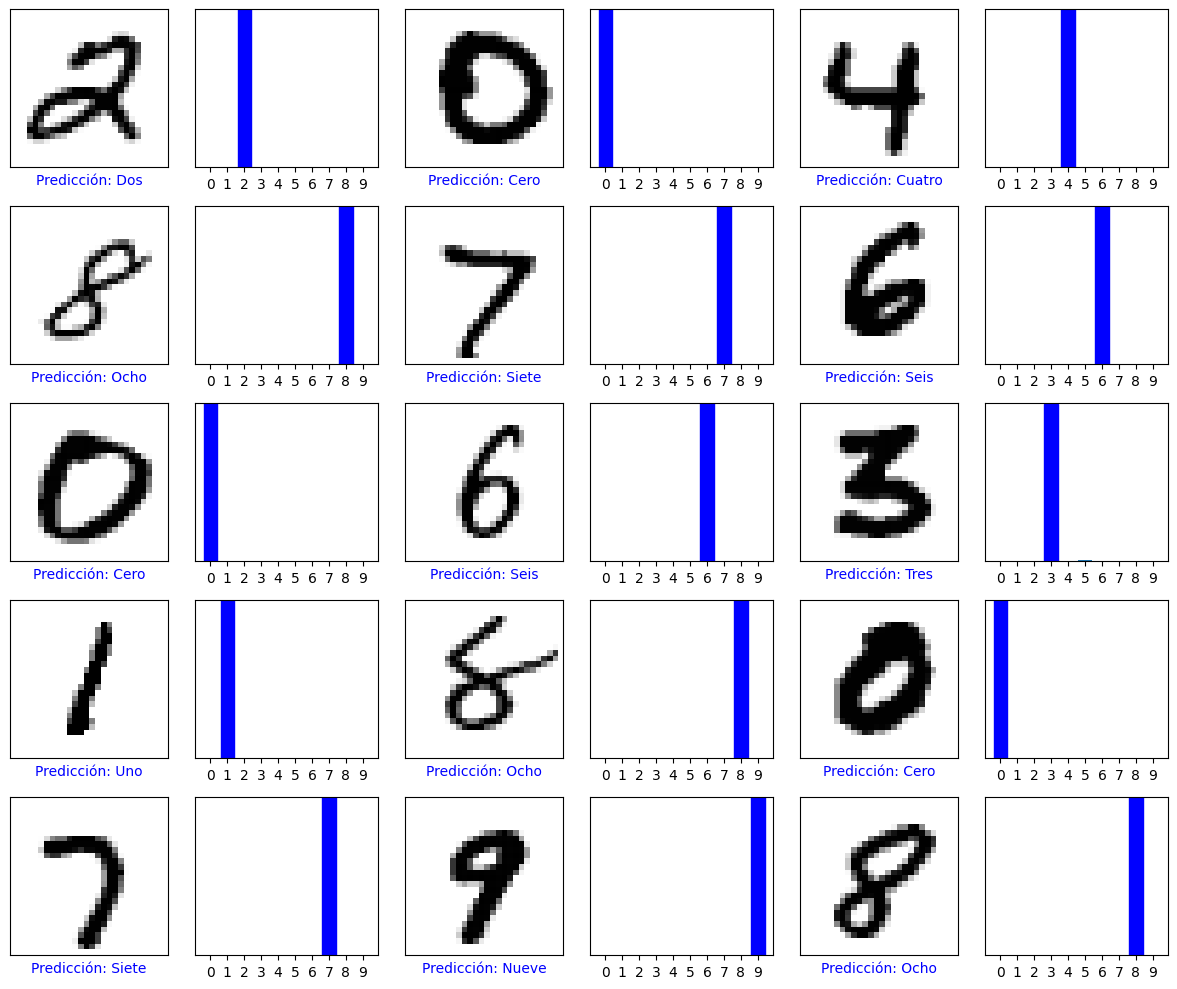

In [27]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)

    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()

In [28]:
model.save("modelo_numeros.h5")